In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


In [2]:
gen1 = pd.read_csv("Plant_1_Generation_Data.csv")
weather1 = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

gen2 = pd.read_csv("Plant_2_Generation_Data.csv")
weather2 = pd.read_csv("Plant_2_Weather_Sensor_Data.csv")

In [3]:
data1 = pd.merge(gen1, weather1, on="DATE_TIME")
data2 = pd.merge(gen2, weather2, on="DATE_TIME")
data = pd.concat([data1, data2], ignore_index=True)

In [4]:
data.dropna(inplace=True)
data.drop_duplicates(inplace=True)


In [5]:

# Remove NIGHT DATA (huge improvement)
data = data[data['IRRADIATION'] > 0]

In [6]:
# STEP 7: Feature Engineering

# Convert to datetime (safe conversion)
data['DATE_TIME'] = pd.to_datetime(data['DATE_TIME'], errors='coerce')

# Drop rows where conversion failed (important)
data = data.dropna(subset=['DATE_TIME'])

# Extract time-based features
data['hour'] = data['DATE_TIME'].dt.hour
data['month'] = data['DATE_TIME'].dt.month

# Define features and target
features = [
    'AMBIENT_TEMPERATURE',
    'MODULE_TEMPERATURE',
    'IRRADIATION',
    'hour',
    'month'
]

target = 'DC_POWER'

# Input and output
X = data[features]
y = data[target]

/tmp/ipykernel_403/1236279746.py:4: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['DATE_TIME'] = pd.to_datetime(data['DATE_TIME'], errors='coerce')


In [7]:
# STEP 8: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

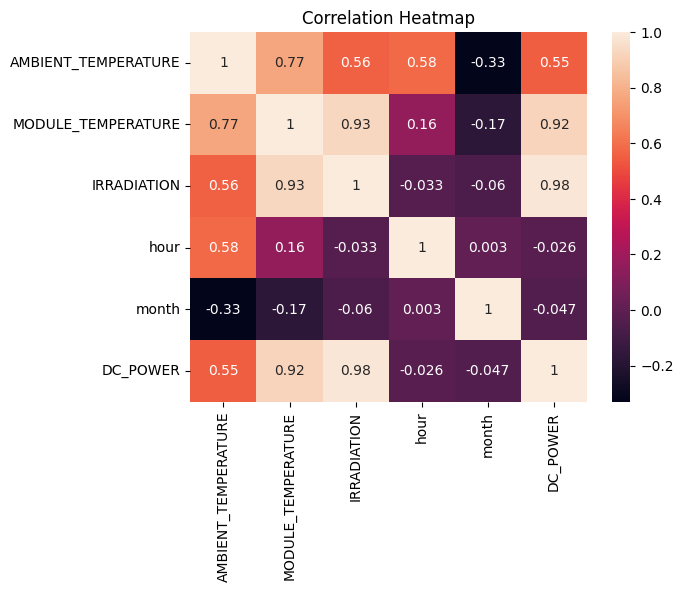

In [8]:
# STEP 9: Visualization
plt.figure()
sns.heatmap(data[features + [target]].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [9]:
rf = RandomForestRegressor(n_estimators=200, max_depth=12)
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6)

In [ ]:

print("Random Forest CV:", cross_val_score(rf, X, y, cv=5, scoring='r2').mean())
print("XGBoost CV:", cross_val_score(xgb, X, y, cv=5, scoring='r2').mean())


In [ ]:
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
xgb_preds = xgb.predict(X_test)

In [ ]:
def evaluate(y_true, preds):
    return (
        r2_score(y_true, preds),
        mean_absolute_error(y_true, preds),
        np.sqrt(mean_squared_error(y_true, preds))
    )

rf_metrics = evaluate(y_test, rf_preds)
xgb_metrics = evaluate(y_test, xgb_preds)

print("\nRandom Forest:", rf_metrics)
print("XGBoost:", xgb_metrics)

In [ ]:
best_model = rf if rf_metrics[0] > xgb_metrics[0] else xgb
best_preds = rf_preds if rf_metrics[0] > xgb_metrics[0] else xgb_preds

print("\nBest Model:", "Random Forest" if best_model == rf else "XGBoost")

In [ ]:
# Actual vs Predicted
plt.scatter(y_test, best_preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()


In [ ]:
# Residual Plot
residuals = y_test - best_preds
plt.scatter(best_preds, residuals)
plt.axhline(y=0)
plt.title("Residual Plot")
plt.show()

In [ ]:
# Feature Importance
if hasattr(best_model, "feature_importances_"):
    pd.Series(best_model.feature_importances_, index=features).plot(kind='bar')
    plt.title("Feature Importance")
    plt.show()

In [ ]:
import numpy as np
import joblib

sample = [30, 35, 800, 12, 6]


sample = np.array(sample).reshape(1, -1)



prediction = best_model.predict(sample)

print("\nPredicted Solar Power:", prediction[0])